# Creating an environment in Gymnasium

In this exercise we will learn how to make simple environments in Gymnasium. This will allow you to model your own problems and apply Reinforcement Learning methods that you learn in the course. In this exercise we will implement the Gambler's Problem from Example 4.3 and Exercise 4.9 from the book. This is the same problem that we also saw in the last tutorial, where we applied Value Iteration on it. In this exercise we have already given an implementation of TD(0) which you can apply on the environment.

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import sys

We will create the environment using classes. By supplying the input gym.Env to this class it will inherit base properties from the gym.Env class from Gymnasium. To complete the environment, we have to define 3 functions.

1. The __init__ function is called whenever we create the environment. In this function we initialize the properties of our environment. 
2. The reset function should reset the environment to an initial position. It should save this state as a class attribute. reset() should be called whenever we start a new episode.
3. The step function performs a step in the environment for a supplied action. It applies this action on the current state of the environment (this state should be saved as a class attribute). It then determines the new state, reward and if the episode is done. These are returned as outputs. Furthermore, it should update the state class attribute to the new state.

In [2]:
class GamblersProblem(gym.Env):
    def __init__(self, nS=100, p_h=0.5):
        # Initialize state and action space
        self.observation_space = spaces.Discrete(nS+1)
        self.action_space = spaces.Discrete(nS-1)
        
        # Store amount of states and probability of heads
        self.nS = nS
        self.heads = p_h
        
    def reset(self):
        self.state = np.random.randint(1,self.nS)
        return self.state
    
    def step(self, action):
        # Cap the action amount: i.e. we can't bid more than we have or more than half of the total winnings
        action = min(action, self.state, self.nS-self.state)
        
        # Flip a coin, win or lose action amount depending on heads or teals
        heads = (self.heads > np.random.rand())
        if heads:
            next_state = self.state + action
        else:
            next_state = self.state - action
                        
        # Make sure that our state is an integer
        next_state = int(next_state)
        
        # Set reward and done variables for terminal states. 
        # done=True for 0 and final state, done=False otherwise
        # reward=1 for final state, reward=0 otherwise
        reward = 0
        done = False
        if next_state == 0:
            done = True
        elif next_state == self.nS:
            done = True
            reward = 1
        
        self.state = next_state
               
        return next_state, reward, done, {}

Below we have given an implementation of TD(0). This algorithm is a one-step method that evaluates a policy applied on the environment.

In [14]:
def TD0(env, policy, num_episodes, discount_factor=1.0, alpha=0.01):
    """
    TD(0) algorithm: one-step TD prediction. Finds value function for a policy.
    
    Args:
        env: Gymnasium environment.
        policy: The (deterministic) policy to be evaluated. 
                Input should be a dictionary with states as keys and actions as values.
        num_episodes: Number of episodes to run for.
        discount_factor: Gamma discount factor.
        alpha: TD learning rate.
    
    Returns:
        A tuple (Q, stats).
        V is the state-value function of policy pi, a dictionary mapping state -> value.
    """
    nS = env.observation_space.n    
    nA = env.action_space.n
    # The state-value function V. Maps states to values
    V = {}
    for s in range(nS):
        V[s] = 0
        
    # Loop over the episodes
    for i in range(num_episodes):
        # Print every 100 episodes.
        if (i + 1) % 100 == 0:
            print("\rEpisode {}/{}.".format(i + 1, num_episodes), end="")
            sys.stdout.flush()
        
        # Reset the environment and pick the first action
        state = env.reset()
                
        # Perform one episode
        done = False
        while not done:
            # Select an action from our policy 
            action = policy[int(state)]
                        
            # Take a step
            next_state, reward, done, _ = env.step(action)

            # TD Update
            td_target = reward + discount_factor * V[next_state]
            td_delta = td_target - V[state]
            V[state] += alpha * td_delta
    
            if done:
                break             
            state = next_state          
    return V

In the next 3 code cells we first define the environment. Here you can give inputs to the model, such as the number of states, i.e. the maximum amount that the gambler can win, and the probability of flipping heads on the coin. Then we have defined some policies for which we can apply TD(0) on the environment. Here you can of course also try out other policies and you can also play around with the parameter values $\alpha$ and $\epsilon$. Finally you can plot the resulting value function.

In [15]:
# Make the environment
nS = 100
p_h = 0.25
env = GamblersProblem(nS, p_h)

In [16]:
# Initialize policies

# Policy where we always bet 1
policy = np.ones(nS+1)
policy[0] = 0
policy[nS] = 0

# Policy where we bet maximally
policy2 = np.zeros(nS+1)
for s in range(1, nS):
    policy2[s] = min(s,nS-s)    

# Run TD(0) on our environment
V = TD0(env, policy2, 100000)

Episode 100000/100000.

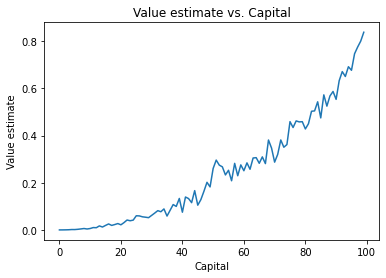

In [17]:
# Plotting Value estimate vs. Capital
x = range(nS)
y = list(V.values())[:nS]

# Plot
plt.plot(x, y)
plt.xlabel("Capital")
plt.ylabel("Value estimate")
plt.title("Value estimate vs. Capital")
plt.show()